In [1]:
!pip install datasets transformers

In [2]:
import pandas as pd
import torch
import numpy as np
import re
import time
import random
import datetime
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
from bs4 import BeautifulSoup
from datasets import Dataset, DatasetDict
from google.colab import drive
from torch.utils.data import Dataset, DataLoader, random_split, RandomSampler, SequentialSampler
from transformers import GPT2Tokenizer, GPT2LMHeadModel, GPT2Config, get_linear_schedule_with_warmup, StoppingCriteria, StoppingCriteriaList

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


0           Mid-Level Professional
1    Senior Individual Contributor
2    Senior Individual Contributor
3               Executive/Director
4           Mid-Level Professional
Name: y_true_mapped, dtype: object


<Axes: xlabel='y_true_mapped'>

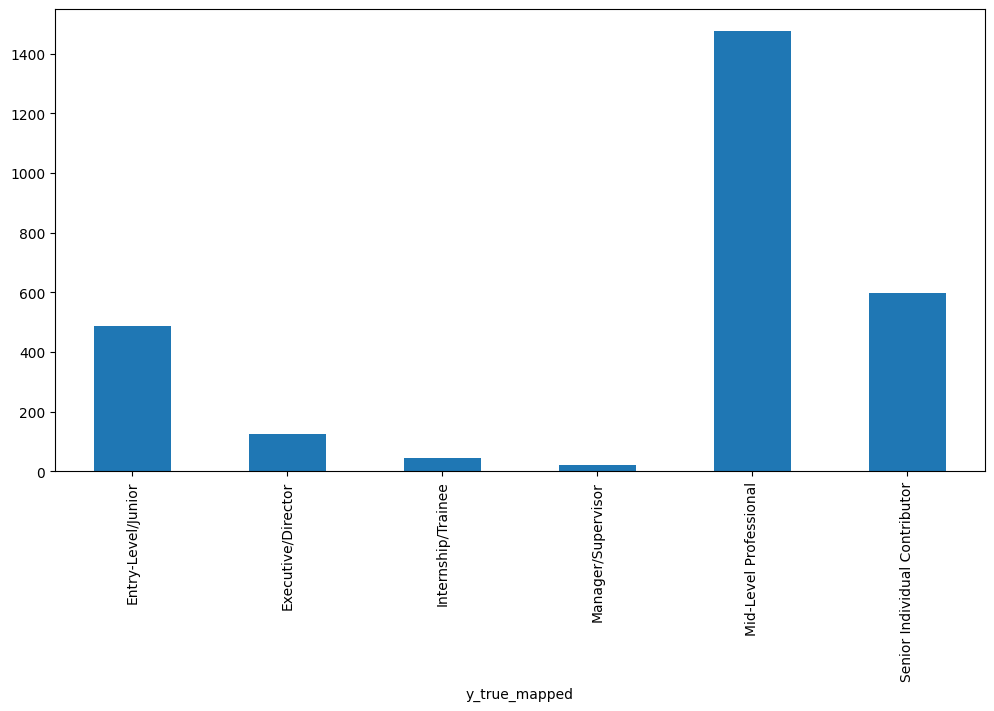

In [4]:
# Load test data
df_train = pd.read_csv('/content/drive/My Drive/Colab Notebooks/job_data_files/seniority_labelled_development_set_mapped.csv')
df_test = pd.read_csv('/content/drive/My Drive/Colab Notebooks/job_data_files/seniority_labelled_test_set_mapped.csv')

# Define a helper function to remove HTML tags from text.
def clean_html(text):
    if pd.isnull(text):
        return ""
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

# Clean job_ad_details and create a new column
df_train['job_ad_details_clean'] = df_train['job_ad_details'].apply(clean_html)
df_test['job_ad_details_clean'] = df_test['job_ad_details'].apply(clean_html)

print(df_train['y_true_mapped'].head())

df_train.groupby("y_true_mapped").size().plot.bar(figsize=(12, 6))

In [5]:
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=42)

df_train['input_text'] = (
    "Job Title: (" + df_train['job_title'].fillna('') + ") " +
    "Job Summary: (" + df_train['job_summary'].fillna('') + ") " +
    "Classification Name: (" + df_train['classification_name'].fillna('')  + ") " +
    "Subclassification Name: (" + df_train['subclassification_name'].fillna('') + ") " +
    "Job Ad Details: (" + df_train['job_ad_details_clean'].fillna('') + ") " +
    "Seniority Level: (" + df_train['y_true_mapped'] + ")"
)


df_val['input_text'] = (
    "Job Title: (" + df_val['job_title'].fillna('') + ") " +
    "Job Summary: (" + df_val['job_summary'].fillna('') + ") " +
    "Classification Name: (" + df_val['classification_name'].fillna('')  + ") " +
    "Subclassification Name: (" + df_val['subclassification_name'].fillna('') + ") " +
    "Job Ad Details: (" + df_val['job_ad_details_clean'].fillna('') + ") " +
    "Seniority Level: ("
)


df_test['input_text'] = (
    "Job Title: (" + df_test['job_title'].fillna('') + ") " +
    "Job Summary: (" + df_test['job_summary'].fillna('') + ") " +
    "Classification Name: (" + df_test['classification_name'].fillna('')  + ") " +
    "Subclassification Name: (" + df_test['subclassification_name'].fillna('') + ") " +
    "Job Ad Details: (" + df_test['job_ad_details_clean'].fillna('') + ") " +
    "Seniority Level: ("
)

# Show a preview of the cleaned data
print(df_train['input_text'].head())

1029    Job Title: (Marketing and communications speci...
1623    Job Title: (Disability Support Workers North W...
1791    Job Title: (Senior Manger Internal Audit  ) Jo...
1652    Job Title: (Sheetmetal Fabrication CoOrdinator...
2516    Job Title: (Room Leader - Croydon) Job Summary...
Name: input_text, dtype: object


In [6]:
# Load the GPT tokenizer.
tokenizer = GPT2Tokenizer.from_pretrained("openai-community/gpt2-medium", bos_token='<|startoftext|>', eos_token='<|endoftext|>', pad_token='<|pad|>')

tokenizer.padding_side = 'right'  # Ensure padding is on the right
tokenizer.truncation_side = 'left'  # Truncate from the left

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
batch_size = 8

In [8]:
class GPT2Dataset(Dataset):

  def __init__(self, txt_list, tokenizer, max_length=1024):

    self.tokenizer = tokenizer
    self.input_ids = []
    self.attn_masks = []

    for txt in txt_list:

      encodings_dict = tokenizer('<|startoftext|>'+ txt + '<|endoftext|>', truncation=True, max_length=max_length, padding="max_length")

      self.input_ids.append(torch.tensor(encodings_dict['input_ids']))
      self.attn_masks.append(torch.tensor(encodings_dict['attention_mask']))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.attn_masks[idx]

In [9]:
train_dataset = GPT2Dataset(df_train['input_text'], tokenizer)

def process_data(df):
    tokenized_input = tokenizer.encode(df['input_text'], return_tensors="pt")
    # Slice from the beginning to keep only the last 1000 tokens
    return tokenized_input[:, -1000:]

df_val['input_ids'] = df_val.apply(process_data, axis=1)
df_test['input_ids'] = df_test.apply(process_data, axis=1)

print('{:>5,} training samples'.format(len(train_dataset)))
print('{:>5,} validation samples'.format(len(df_val)))
print('{:>5,} testing samples'.format(len(df_test)))

Token indices sequence length is longer than the specified maximum sequence length for this model (1122 > 1024). Running this sequence through the model will result in indexing errors


2,476 training samples
  276 validation samples
  689 testing samples


In [10]:
# Create the DataLoaders for our training and validation datasets.
# We'll take training samples in random order.
train_dataloader = DataLoader(
    train_dataset,               # The training dataset
    sampler=RandomSampler(train_dataset),  # Select batches randomly
    batch_size=batch_size,       # Training batch size
    pin_memory=True              # Enable pinned memory
)

In [11]:
# I'm not really doing anything with the config buheret
configuration = GPT2Config.from_pretrained('openai-community/gpt2-medium', output_hidden_states=False)

# instantiate the model
model = GPT2LMHeadModel.from_pretrained("openai-community/gpt2-medium", config=configuration)

# this step is necessary because I've added some tokens (bos_token, etc) to the embeddings
# otherwise the tokenizer and model tensors won't match up
model.resize_token_embeddings(len(tokenizer))

# Tell pytorch to run this model on the GPU.
device = torch.device("cuda")
model.cuda()

# Set the seed value all over the place to make this reproducible.
seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [12]:
# Define a custom stopping criterion that stops generation when a specific token is produced.
class StopOnToken(StoppingCriteria):
    def __init__(self, token_id):
        self.token_id = token_id

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor, **kwargs) -> bool:
        # Check if the last token in the sequence is the stop token.
        # input_ids shape: [batch_size, sequence_length]
        if input_ids[0, -1] == self.token_id:
            return True
        return False

# Get the token id for the closing parenthesis: ')'
stop_token_id = tokenizer.encode(")")[0]

# Create a stopping criteria list with our custom criterion
stopping_criteria = StoppingCriteriaList([StopOnToken(stop_token_id)])

In [13]:
# some parameters I cooked up that work reasonably well
epochs = 5
learning_rate = 0.0008
warmup_steps = 1e2
epsilon = 1e-8

# this produces sample output every 100 steps
sample_every = 100

In [14]:
# Note: AdamW is a class from the huggingface library (as opposed to pytorch)
optimizer = AdamW(model.parameters(),
          lr = learning_rate,
          eps = epsilon
          )

In [15]:
# Total number of training steps is [number of batches] x [number of epochs].
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
# This changes the learning rate as the training loop progresses
scheduler = get_linear_schedule_with_warmup(optimizer,
                       num_warmup_steps = warmup_steps,
                       num_training_steps = total_steps)

In [16]:
def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round((elapsed)))))

In [17]:
total_t0 = time.time()
training_stats = []
model = model.to(device)

for epoch_i in range(0, epochs):

    # ========================================
    #               Training
    # ========================================

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    t0 = time.time()
    total_train_loss = 0
    model.train()

    for step, batch in enumerate(tqdm(train_dataloader)):

        b_input_ids = batch[0].to(device, non_blocking=True)
        b_labels = batch[0].to(device, non_blocking=True)
        b_masks = batch[1].to(device, non_blocking=True)

        model.zero_grad()

        outputs = model(b_input_ids,
                 labels=b_labels,
                 attention_mask = b_masks,
                 token_type_ids=None
                 )

        loss = outputs[0]

        batch_loss = loss.item()
        total_train_loss += batch_loss

        loss.backward()
        optimizer.step()
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))

    # ========================================
    #               Validation
    # ========================================

    print("")
    print("Running Validation...")

    t0 = time.time()

    model.eval()

    total_eval_acc = 0
    nb_eval_steps = 0

    # Evaluate data for one epoch
    model.eval()

    for tokenized_input, true_output in zip(df_val['input_ids'], df_val['y_true_mapped']):

        tokenized_input = tokenized_input.to(device)
        attention_mask = torch.ones(tokenized_input.shape, device=device)

        outputs = model.generate(input_ids=tokenized_input,
                      attention_mask=attention_mask,
                      pad_token_id=tokenizer.pad_token_id,
                      do_sample=True,
                      top_k=20,
                      max_new_tokens=10,
                      top_p=0.95,
                      num_return_sequences=1,
                      stopping_criteria=stopping_criteria)
        generated_tokens = outputs[0, tokenized_input.size(1)-1:]

        generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

        # Use a regular expression to capture the text between the first "(" and the first ")".
        match = re.search(r'\((.*?)\)', generated_text)
        if match:
            # This will capture the text inside the parentheses.
            extracted_text = match.group(1)
        else:
            extracted_text = generated_text[2:]  # Fallback in case no matching pattern is found

        if extracted_text == true_output:
            total_eval_acc += 1

    avg_val_acc = total_eval_acc / len(df_val)

    model.train()

    validation_time = format_time(time.time() - t0)

    print("  Validation Acc: {0:.3f}".format(avg_val_acc))
    print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            'Valid. Acc': avg_val_acc,
            'Training Time': training_time,
            'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


======== Epoch 1 / 5 ========
Training...


100%|██████████| 310/310 [06:45<00:00,  1.31s/it]



  Average training loss: 1.81
  Training epoch took: 0:06:45

Running Validation...
  Validation Acc: 0.580
  Validation took: 0:00:32

======== Epoch 2 / 5 ========
Training...


100%|██████████| 310/310 [06:45<00:00,  1.31s/it]



  Average training loss: 1.05
  Training epoch took: 0:06:45

Running Validation...
  Validation Acc: 0.743
  Validation took: 0:00:30

======== Epoch 3 / 5 ========
Training...


...


  Average training loss: 0.83
  Training epoch took: 0:06:45

Running Validation...
  Validation Acc: 0.703
  Validation took: 0:00:31

======== Epoch 4 / 5 ========
Training...


100%|██████████| 310/310 [06:45<00:00,  1.31s/it]



  Average training loss: 0.59
  Training epoch took: 0:06:45

Running Validation...
  Validation Acc: 0.746
  Validation took: 0:00:30

======== Epoch 5 / 5 ========
Training...


100%|██████████| 310/310 [06:45<00:00,  1.31s/it]



  Average training loss: 0.39
  Training epoch took: 0:06:45

Running Validation...
  Validation Acc: 0.736
  Validation took: 0:00:30

Training complete!
Total training took 0:36:19 (h:mm:ss)


In [18]:
save_path = "/content/drive/MyDrive/Colab Notebooks/GPT2/fine-tuned_GPT2_seniority_model.pth"  # Adjust the path as needed
torch.save(model.state_dict(), save_path)
print(f"Model state saved to: {save_path}")

Model state saved to: /content/drive/MyDrive/Colab Notebooks/GPT2/fine-tuned_GPT2_seniority_model.pth


In [19]:
# Lists to hold predicted and true labels
predictions = []
true_labels = []

model.eval()

for text, tokenized_input, true_output in zip(df_test['input_text'], df_test['input_ids'], df_test['y_true_mapped']):
    # Move tokenized input to device
    tokenized_input = tokenized_input.to(device)

    # Create an attention mask (full ones since there's no padding)
    attention_mask = torch.ones(tokenized_input.shape, device=device)

    # Generate outputs using the model (using the same generation parameters)
    outputs = model.generate(
        input_ids=tokenized_input,
        attention_mask=attention_mask,
        pad_token_id=tokenizer.pad_token_id,  # Explicitly set pad_token_id
        do_sample=True,
        top_k=20,
        max_new_tokens=10,
        top_p=0.95,
        num_return_sequences=1,
        stopping_criteria=stopping_criteria
    )

    # Extract only the newly generated tokens (adjust the slicing if needed)
    generated_tokens = outputs[0, tokenized_input.size(1)-1:]

    # Decode tokens into text
    generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    # Use regex to capture the text between the first "(" and the first ")"
    match = re.search(r'\((.*?)\)', generated_text)
    if match:
        extracted_text = match.group(1)
    else:
        extracted_text = generated_text[2:]  # Fallback if no pattern is found

    # Append the predicted and true labels for later evaluation
    predictions.append(extracted_text)
    true_labels.append(true_output)
    if extracted_text != true_output:
        print(f"\nInput text: {text}\nWrong Predicted: {extracted_text}\nTrue: {true_output}")


Input text: Job Title: (Residential Site Manager - Melbourne CBD - Housing & apartments) Job Summary: (Housing & Apartment Site Manager for a Tier 1 Residential developer renowned nationwide. Previous experience in a T1/T2 would be desired.) Classification Name: (Construction) Subclassification Name: (Foreperson/Supervisors) Job Ad Details: (Residential Site Manager - Melbourne CBD - Renowned Land & Housing Developer Denovo Recruitment are currently working with a Tier 1 Residential Developer who are looking for an accomplished Residential (Housing & apartments) Site manager to manage projects of up to $5M, based out of Central Melbourne. The company boasts circa to 100 years heritage and is renowned throughout the whole of Australia and internationally. They truly pride themselves on being a market leader and producing a healthy and supportive work environment for all employees, from site to back office personnel. Despite the housing market slowing down nationally, this client has co

In [20]:
# Calculate accuracy
avg_test_acc = accuracy_score(true_labels, predictions)
print("Average Test Accuracy: {:.3f}%".format(avg_test_acc * 100))

# Calculate Precision, Recall, and F1 Score
# Adjust the average parameter depending on your dataset (e.g., "macro", "weighted", or "binary")
precision = precision_score(true_labels, predictions, average='weighted', zero_division=0)
recall = recall_score(true_labels, predictions, average='weighted', zero_division=0)
f1 = f1_score(true_labels, predictions, average='weighted', zero_division=0)

print("Precision: {:.3f}".format(precision))
print("Recall: {:.3f}".format(recall))
print("F1 Score: {:.3f}".format(f1))

# Print the full classification report
print("Classification Report:\n", classification_report(true_labels, predictions, zero_division=0))

Average Test Accuracy: 74.746%
Precision: 0.743
Recall: 0.747
F1 Score: 0.742
Classification Report:
                                precision    recall  f1-score   support

           Entry-Level/Junior       0.77      0.63      0.69       131
           Executive/Director       0.54      0.41      0.47        34
           Internship/Trainee       0.86      0.67      0.75        18
           Manager/Supervisor       0.00      0.00      0.00         4
       Mid-Level Professional       0.78      0.84      0.81       361
Senior Individual Contributor       0.68      0.72      0.70       141

                     accuracy                           0.75       689
                    macro avg       0.60      0.55      0.57       689
                 weighted avg       0.74      0.75      0.74       689



Best Epoch: 4


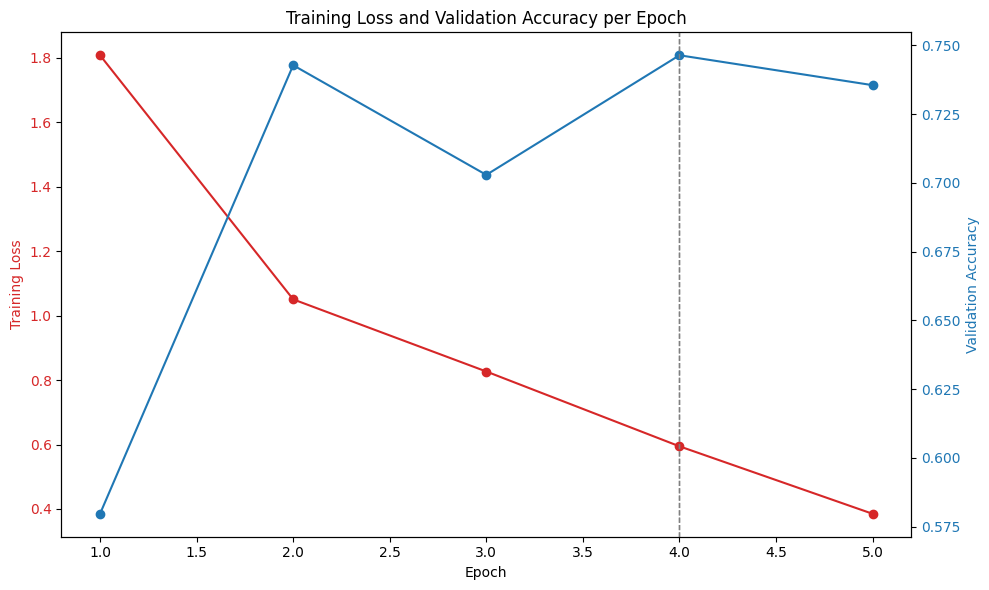

In [21]:
# Extract the data from training_stats.
epochs = [entry['epoch'] for entry in training_stats]
train_loss = [entry['Training Loss'] for entry in training_stats]
valid_acc = [entry['Valid. Acc'] for entry in training_stats]

# Optional: Determine the best epoch based on validation accuracy.
best_epoch = epochs[valid_acc.index(max(valid_acc))]
print("Best Epoch:", best_epoch)

# Create a plot with two y-axes: one for Training Loss and one for Validation Accuracy.
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot the Training Loss on the primary y-axis.
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(epochs, train_loss, color=color, marker='o', label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for Validation Accuracy.
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Validation Accuracy', color=color)
ax2.plot(epochs, valid_acc, color=color, marker='o', label='Validation Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and a legend.
plt.title('Training Loss and Validation Accuracy per Epoch')
fig.tight_layout()  # Ensure the layout fits the figure area

# Optionally, mark the best epoch on the plot with a vertical line
ax1.axvline(x=best_epoch, color='gray', linestyle='--', linewidth=1)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', linewidth=1)

plt.show()